In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import calendar

In [2]:
bollywood_df = pd.read_csv('DATA/bollywood .csv')

In [3]:
bollywood_df.head()

,SlNo,Release Date,MovieName,ReleaseTime,Genre,Budget,BoxOfficeCollection,YoutubeViews,YoutubeLikes,YoutubeDislikes
0,1,18-Apr-14,2 States,LW,Romance,36,104.00,8576361,26622,2527.0
1,2,4-Jan-13,Table No. 21,N,Thriller,10,12.00,1087320,1129,137.0
2,3,18-Jul-14,Amit Sahni Ki List,N,Comedy,10,4.00,572336,586,54.0
3,4,4-Jan-13,Rajdhani Express,N,Drama,7,0.35,42626,86,19.0
4,5,4-Jul-14,Bobby Jasoos,N,Comedy,18,10.80,3113427,4512,1224.0


In [4]:
bollywood_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   SlNo                 149 non-null    int64  
 1   Release Date         149 non-null    str    
 2   MovieName            149 non-null    str    
 3   ReleaseTime          149 non-null    str    
 4   Genre                149 non-null    str    
 5   Budget               149 non-null    int64  
 6   BoxOfficeCollection  149 non-null    float64
 7   YoutubeViews         149 non-null    int64  
 8   YoutubeLikes         149 non-null    int64  
 9   YoutubeDislikes      146 non-null    float64
dtypes: float64(2), int64(4), str(4)
memory usage: 15.8 KB


In [5]:
bollywood_df.columns

Index(['SlNo', 'Release Date', 'MovieName', 'ReleaseTime', 'Genre', 'Budget',
       'BoxOfficeCollection', 'YoutubeViews', 'YoutubeLikes',
       'YoutubeDislikes'],
      dtype='str')

In [6]:
sum(bollywood_df['YoutubeDislikes'].isnull())

3

In [7]:
bollywood_df.shape[0]

149

In [8]:
bollywood_df['Genre'].unique()

<ArrowStringArray>
['Romance', 'Thriller', 'Comedy', 'Drama', 'Action']
Length: 5, dtype: str

In [9]:
bollywood_df['Genre'].value_counts().to_frame('Count')

,Count
Genre,
Comedy,36
Drama,35
Thriller,29
Romance,25
Action,24


In [10]:
## genre with highest count
bollywood_df['Genre'].value_counts().idxmax()

'Comedy'

In [11]:
# genre with minimum count
bollywood_df['Genre'].value_counts().idxmin()

'Action'

In [12]:
# count movies by release time and genre
bollywood_df.groupby(['ReleaseTime', 'Genre']).size().unstack(fill_value=0)

Genre,Action,Comedy,Drama,Romance,Thriller
ReleaseTime,,,,,
FS,3,3,4,3,4
HS,3,5,6,3,1
LW,3,5,1,4,2
N,15,23,24,15,22


In [13]:
# which month of the year, maximum number movie releases are seen?
bollywood_df['Month'] = pd.to_datetime(bollywood_df['Release Date'], format='%d-%b-%y').dt.month
bollywood_df['Month'].value_counts().idxmax()

np.int32(1)

In [14]:
bollywood_df.groupby(['Month','ReleaseTime']).size().unstack(fill_value=0)

ReleaseTime,FS,HS,LW,N
Month,,,,
1,0,0,3,17
2,3,0,0,13
3,2,0,0,17
4,1,0,5,5
5,0,12,1,5
6,0,5,0,5
7,0,0,0,16
8,2,0,1,5
9,0,0,3,7


In [15]:
# which month of the year, maximum number movie releases are seen?
bollywood_df["Release Date"] = pd.to_datetime(
    bollywood_df["Release Date"],
    format="%d-%b-%y",
    errors="coerce"
)

most_released_month = bollywood_df["Release Date"].dt.month.value_counts().idxmax()
most_released_month

calendar.month_name[most_released_month]

'January'

In [16]:
bollywood_df["Release Date"]

0     2014-04-18
1     2013-01-04
2     2014-07-18
3     2013-01-04
4     2014-07-04
         ...    
144   2015-02-27
145   2015-03-13
146   2015-03-20
147   2015-03-20
148   2014-05-23
Name: Release Date, Length: 149, dtype: datetime64[us]

In [17]:
high_budget = bollywood_df[bollywood_df["Budget"] >= 25]

high_budget["Month"] = pd.to_datetime(
    high_budget["Release Date"],
    format="%d-%b-%y"
).dt.month_name()

high_budget["Month"].value_counts().idxmax()

'February'

In [18]:
bollywood_df["ROI"] = (
    (bollywood_df["BoxOfficeCollection"] - bollywood_df["Budget"])
    / bollywood_df["Budget"]
)

top_10_roi = bollywood_df.nlargest(10, "ROI")[["MovieName", "ROI"]]
top_10_roi

,MovieName,ROI
64,Aashiqui 2,8.166667
89,PK,7.647059
132,Grand Masti,7.514286
135,The Lunchbox,7.500000
87,Fukrey,6.240000
58,Mary Kom,5.933333
128,Shahid,5.666667
37,Humpty Sharma Ki Dulhania,5.500000
101,Bhaag Milkha Bhaag,4.466667
115,Chennai Express,4.266667


In [19]:
average_roi = (
    bollywood_df.groupby("ReleaseTime")["ROI"]
    .agg(['mean','median','count'])
    .sort_values('mean',ascending=False)
)

average_roi

,mean,median,count
ReleaseTime,,,
LW,1.127205,1.105263,15
FS,0.973853,0.466667,17
HS,0.850867,0.084545,18
N,0.657722,0.150000,99


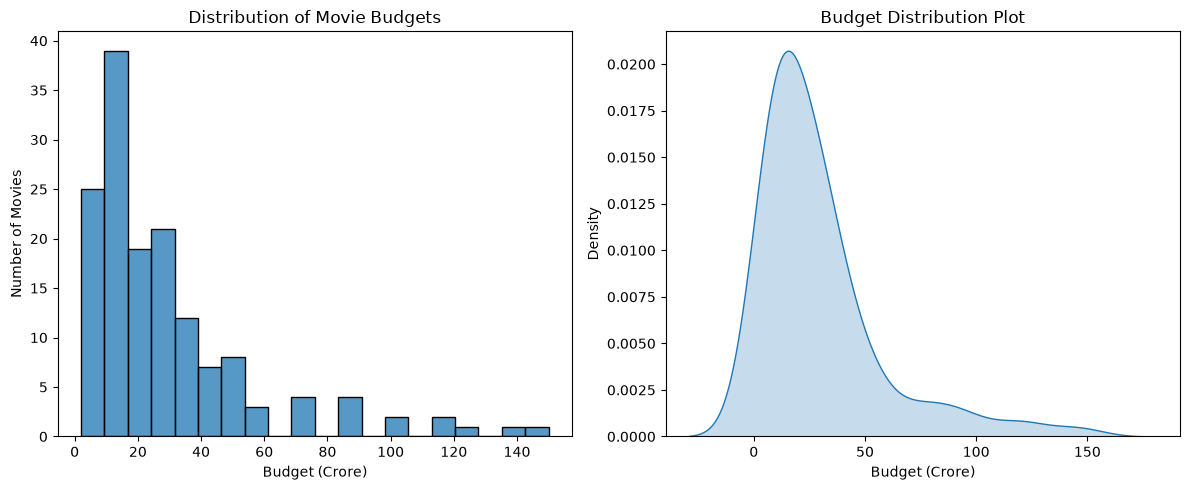

In [20]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sn.histplot(bollywood_df["Budget"], bins=20, kde=False)
plt.title("Distribution of Movie Budgets")
plt.xlabel("Budget (Crore)")
plt.ylabel("Number of Movies")

plt.subplot(1, 2, 2)
sn.kdeplot(bollywood_df["Budget"], fill=True)
plt.title("Budget Distribution Plot")
plt.xlabel("Budget (Crore)")

plt.tight_layout()
plt.show()

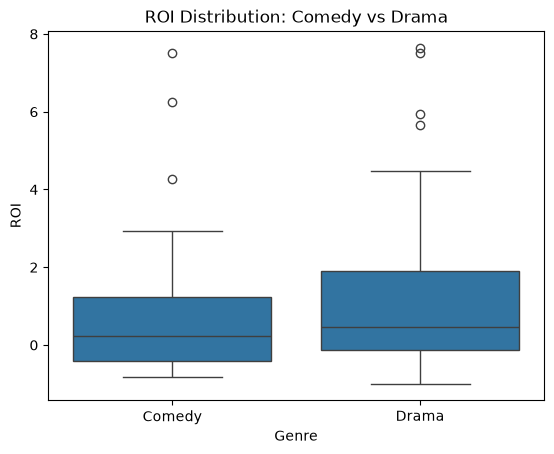

,mean,median,count
Genre,,,
Comedy,0.788394,0.236061,36
Drama,1.357455,0.466667,35


In [21]:
genre_roi = bollywood_df[
    bollywood_df["Genre"].isin(["Comedy", "Drama"])
]

sn.boxplot(data=genre_roi, x="Genre", y="ROI")
plt.title("ROI Distribution: Comedy vs Drama")
plt.xlabel("Genre")
plt.ylabel("ROI")
plt.show()

genre_roi.groupby("Genre")["ROI"].agg(["mean", "median", "count"])

In [22]:
bollywood_df["BoxOfficeCollection"].corr(bollywood_df["YoutubeLikes"])

np.float64(0.6825165877731297)

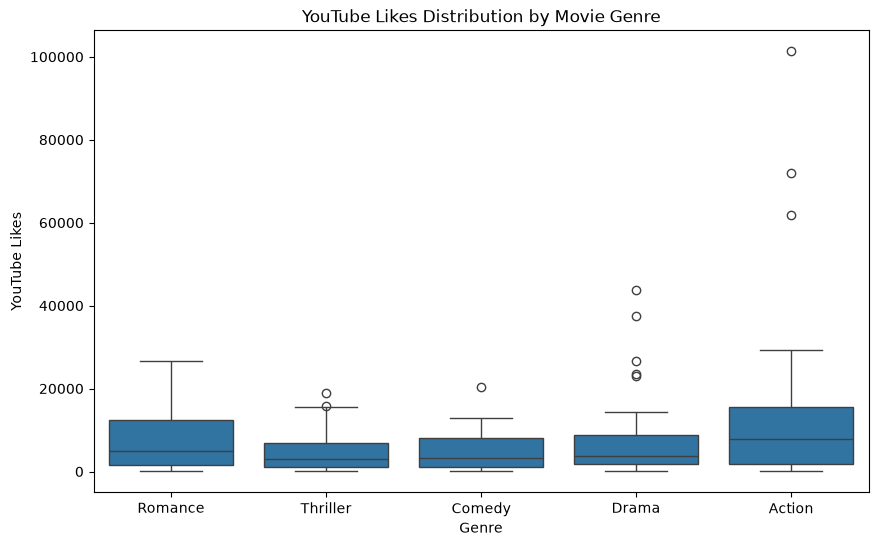

,median,mean,count
Genre,,,
Action,7951.0,16744.708333,24
Romance,4853.0,7089.640000,25
Drama,3656.0,7973.628571,35
Comedy,3365.0,4784.722222,36
Thriller,2974.0,4941.793103,29


In [32]:
plt.figure(figsize=(10, 6))

sn.boxplot(
    data=bollywood_df,
    x="Genre",
    y="YoutubeLikes"
)

plt.title("YouTube Likes Distribution by Movie Genre")
plt.xlabel("Genre")
plt.ylabel("YouTube Likes")
# plt.xticks(rotation=45)
plt.show()

bollywood_df.groupby("Genre")["YoutubeLikes"].agg(["median", "mean", "count"]).sort_values("median", ascending=False)

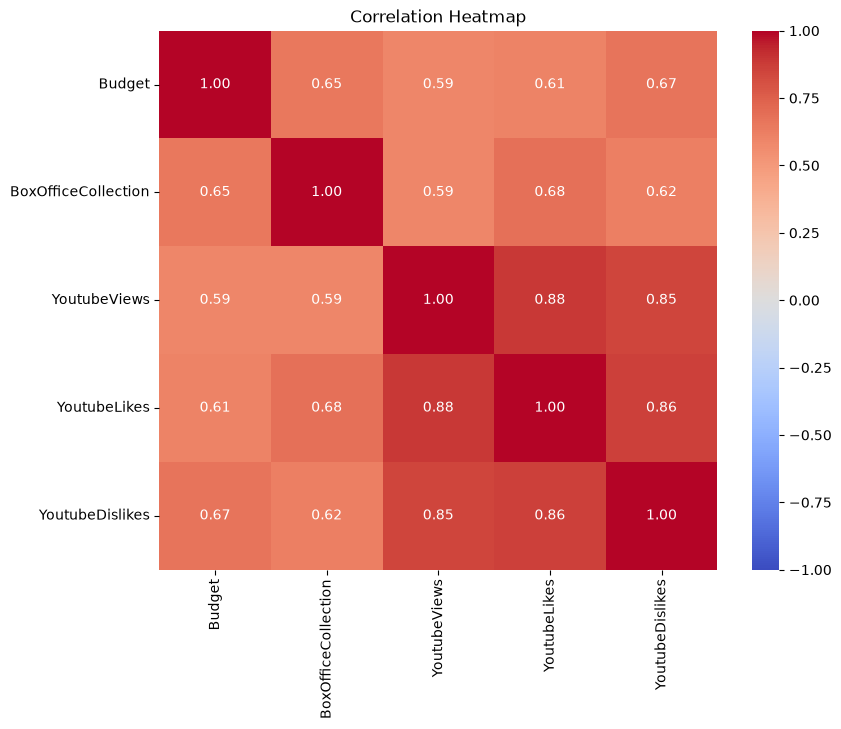

In [24]:
columns = [
    "Budget",
    "BoxOfficeCollection",
    "YoutubeViews",
    "YoutubeLikes",
    "YoutubeDislikes"
]

corr_matrix = bollywood_df[columns].corr()

plt.figure(figsize=(9, 7))
sn.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()